In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
true_path = 'True.csv'
fake_path = 'Fake.csv'

true_df = pd.read_csv(true_path)
fake_df = pd.read_csv(fake_path)

In [4]:
true_df['true'] = 1
fake_df['true'] = 0

df = pd.concat([true_df, fake_df])
display(df)

,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [5]:
true_counts = df['true'].value_counts()

print("Number of Total True News:", true_counts[1])
print("Number of Total Fake news:", true_counts[0])

Number of Total True News: 21417
Number of Total Fake news: 23481


In [6]:
df.drop_duplicates()
df.dropna()

,title,text,subject,date,true
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [7]:
df.drop(columns = ["text","subject","date"])

,title,true
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1
...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,0
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,0
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,0
23479,How to Blow $700 Million: Al Jazeera America F...,0


In [8]:
from sklearn.utils import shuffle

df = df.iloc[:,[0,-1]]
df = df.sample(frac=1).reset_index(drop=True)
display(df)

,title,true
0,"Trump F**ks Up His First Raid, Gets Navy Seal...",0
1,JUST IN: Pro-ISIS Terrorist Who Intended to Bl...,0
2,Powerful Afghan regional leader ousted as poli...,1
3,"Trump EPA pick expresses doubts on climate, de...",1
4,"Once on the outside, conservative Koch network...",1
...,...,...
44893,"Factbox: Break up big banks, end free-trade ag...",1
44894,U.S. ELECTIONS May Already Be In Serious Jeopa...,0
44895,VIDEO: US Elections: More Voter Fraud Emerges,0
44896,German minister threatens action against EU st...,1


In [9]:
df['title'] = (df['title'].str.lower())
print(df)

                                                   title  true
0       trump f**ks up his first raid, gets navy seal...     0
1      just in: pro-isis terrorist who intended to bl...     0
2      powerful afghan regional leader ousted as poli...     1
3      trump epa pick expresses doubts on climate, de...     1
4      once on the outside, conservative koch network...     1
...                                                  ...   ...
44893  factbox: break up big banks, end free-trade ag...     1
44894  u.s. elections may already be in serious jeopa...     0
44895      video: us elections: more voter fraud emerges     0
44896  german minister threatens action against eu st...     1
44897  alaska's top court rejects parental notice for...     1

[44898 rows x 2 columns]


In [10]:
df['title'] = df['title'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
df.head()

,title,true
0,"trump f**ks up his first raid, gets navy seal...",0
1,just in: pro-isis terrorist who intended to bl...,0
2,powerful afghan regional leader ousted as poli...,1
3,"trump epa pick expresses doubts on climate, de...",1
4,"once on the outside, conservative koch network...",1


In [11]:
df['title'] = df['title'].str.replace(r"[\"\'\|\?\=\.\<\>\@\#\*\,]", '')
df.head()

,title,true
0,trump fks up his first raid gets navy seal ki...,0
1,just in: pro-isis terrorist who intended to bl...,0
2,powerful afghan regional leader ousted as poli...,1
3,trump epa pick expresses doubts on climate def...,1
4,once on the outside conservative koch network ...,1


In [12]:
def tokenize(txt):
    tokens = re.split('\W+', txt)
    return tokens

In [13]:
df['title'] = df['title'].apply(lambda x: tokenize(x.lower()))
df.head()

,title,true
0,"[, trump, fks, up, his, first, raid, gets, nav...",0
1,"[just, in, pro, isis, terrorist, who, intended...",0
2,"[powerful, afghan, regional, leader, ousted, a...",1
3,"[trump, epa, pick, expresses, doubts, on, clim...",1
4,"[once, on, the, outside, conservative, koch, n...",1


In [14]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [15]:
def remove_punctuation(txt):
    txt_nopunct = " ".join([c for c in txt if c not in string.punctuation])
    return txt_nopunct

In [16]:
df['title'] = df['title'].apply(lambda x : remove_punctuation(x))
df.head()

,title,true
0,trump fks up his first raid gets navy seal kil...,0
1,just in pro isis terrorist who intended to blo...,0
2,powerful afghan regional leader ousted as poli...,1
3,trump epa pick expresses doubts on climate def...,1
4,once on the outside conservative koch network ...,1


In [17]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
from nltk.corpus import stopwords

In [19]:
",".join(stopwords.words('english'))

"i,me,my,myself,we,our,ours,ourselves,you,you're,you've,you'll,you'd,your,yours,yourself,yourselves,he,him,his,himself,she,she's,her,hers,herself,it,it's,its,itself,they,them,their,theirs,themselves,what,which,who,whom,this,that,that'll,these,those,am,is,are,was,were,be,been,being,have,has,had,having,do,does,did,doing,a,an,the,and,but,if,or,because,as,until,while,of,at,by,for,with,about,against,between,into,through,during,before,after,above,below,to,from,up,down,in,out,on,off,over,under,again,further,then,once,here,there,when,where,why,how,all,any,both,each,few,more,most,other,some,such,no,nor,not,only,own,same,so,than,too,very,s,t,can,will,just,don,don't,should,should've,now,d,ll,m,o,re,ve,y,ain,aren,aren't,couldn,couldn't,didn,didn't,doesn,doesn't,hadn,hadn't,hasn,hasn't,haven,haven't,isn,isn't,ma,mightn,mightn't,mustn,mustn't,needn,needn't,shan,shan't,shouldn,shouldn't,wasn,wasn't,weren,weren't,won,won't,wouldn,wouldn't"

In [20]:
stop_words = set(stopwords.words('english'))

In [21]:
def remove_stop(x):
    return ",".join([word for word in str(x).split() if word not in stop_words])

In [22]:
df['title'] = df['title'].apply(lambda x : remove_stop(x))
df.head()

,title,true
0,"trump,fks,first,raid,gets,navy,seal,killed,dum...",0
1,"pro,isis,terrorist,intended,blow,nyc,bus,termi...",0
2,"powerful,afghan,regional,leader,ousted,politic...",1
3,"trump,epa,pick,expresses,doubts,climate,defend...",1
4,"outside,conservative,koch,network,warms,trump",1


In [23]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [24]:
lemmatizer = WordNetLemmatizer()

In [25]:
def data_processing(data):
    data = [lemmatizer.lemmatize(word) for word in data]
    data = ''.join(data)
    return data

In [26]:
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [27]:
df['title'] = df['title'].apply(lambda data: data_processing(data))
df.head()

,title,true
0,"trump,fks,first,raid,gets,navy,seal,killed,dum...",0
1,"pro,isis,terrorist,intended,blow,nyc,bus,termi...",0
2,"powerful,afghan,regional,leader,ousted,politic...",1
3,"trump,epa,pick,expresses,doubts,climate,defend...",1
4,"outside,conservative,koch,network,warms,trump",1


In [28]:
train_df = df.sample(frac=0.8)
test_df = df.drop(train_df.index)

# reset index
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('trainset size:', train_df.shape)
print('testset size:', test_df.shape)

trainset size: (35918, 2)
testset size: (8980, 2)


In [29]:
print('ISOT length:', len(test_df))

print('Train real news:', train_df[train_df['true']==1].shape[0])
print('Train fake news:', train_df[train_df['true']==0].shape[0])

print('Test real news:', test_df[test_df['true']==1].shape[0])
print('Test fake news:', test_df[test_df['true']==0].shape[0])

ISOT length: 8980
Train real news: 17159
Train fake news: 18759
Test real news: 4258
Test fake news: 4722


In [30]:
X_train = train_df['title']
X_test = test_df['title']

y_train = train_df['true']
y_test = test_df['true']

print('Train data:', X_train.shape, y_train.shape)
print('Test data:', X_test.shape, y_test.shape)

Train data: (35918,) (35918,)
Test data: (8980,) (8980,)


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=10)

X_train_news_tfidf = vectorizer.fit_transform(X_train)
X_test_news_tfidf = vectorizer.transform(X_test)

print('X_train_news_tfidf shape:', X_train_news_tfidf.shape)
print('X_test_news_tfidf shape:', X_test_news_tfidf.shape)

X_train_news_tfidf shape: (35918, 4885)
X_test_news_tfidf shape: (8980, 4885)


In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = MultinomialNB()

param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf,y_train)

best_params = grid_search.best_params_

final_clf = MultinomialNB(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('NB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

NB Classifier
Best hyperparameters: {'alpha': 1.0}
Accuracy:  0.9316258351893095
Precision:  0.9392478302796529
Recall:  0.9149835603569751
F1-score:  0.9269569355222461


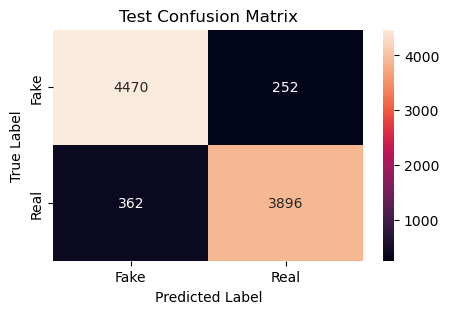

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = RandomForestClassifier()

param_grid = {'max_depth':[None,10,20], 'min_samples_leaf':[1,2,4], 'min_samples_split':[2,5,10], 'n_estimators':[10,50,100]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = RandomForestClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('RF Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

RF Classifier
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy:  0.9326280623608018
Precision:  0.9300682834942312
Recall:  0.927665570690465
F1-score:  0.9288653733098177


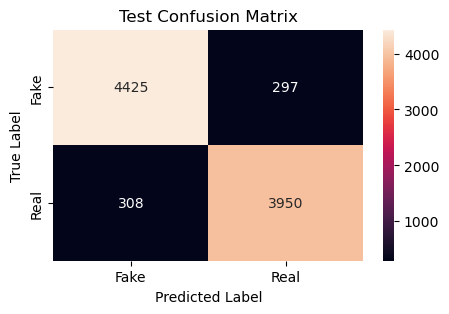

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = LogisticRegression()

param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100], 'penalty':['l1', 'l2']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = LogisticRegression(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('LR Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

LR Classifier
Best hyperparameters: {'C': 10, 'penalty': 'l2'}
Accuracy:  0.9454342984409799
Precision:  0.9412177985948478
Recall:  0.9438703616721466
F1-score:  0.9425422138836773


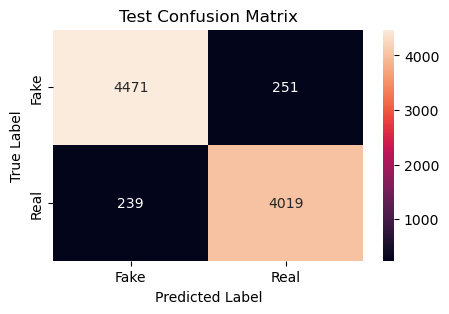

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [38]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = AdaBoostClassifier()

param_grid = {'n_estimators':[50,100,200], 'learning_rate':[0.01, 0.1, 1.0]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = AdaBoostClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('AdaB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

AdaB Classifier
Best hyperparameters: {'learning_rate': 1.0, 'n_estimators': 200}
Accuracy:  0.8923162583518931
Precision:  0.8638072076055715
Recall:  0.9175669328323156
F1-score:  0.889875868352124


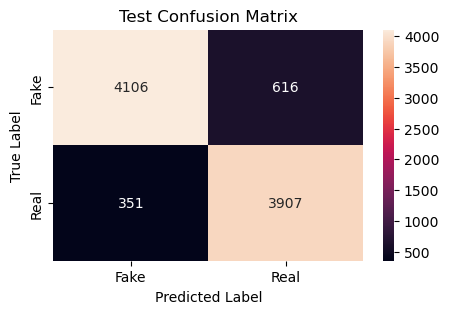

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = KNeighborsClassifier()

param_grid = {'n_neighbors':[3,5,7,9], 'weights':['uniform','distance'], 'p':[1,2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = KNeighborsClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('KNN Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

KNN Classifier
Best hyperparameters: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Accuracy:  0.6194877505567928
Precision:  0.9805714285714285
Recall:  0.20150305307656177
F1-score:  0.33430742255990653


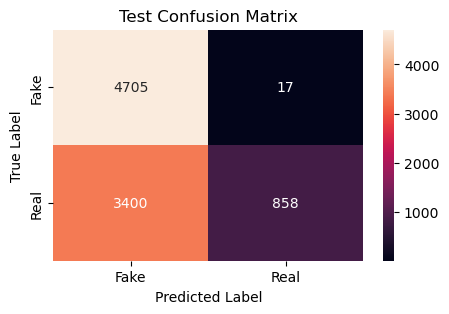

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [42]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = XGBClassifier()

param_grid = {'learning_rate':[0.01,0.1,0.2], 'n_estimators':[50,100,200], 'max_depth':[3,5,7], 'subsample':[0.8,1.0], 'colsample_bytree':[0.8,1.0], 'gamma':[0,0.1,0.2]}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = XGBClassifier(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('XGB Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

XGB Classifier
Best hyperparameters: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Accuracy:  0.9115812917594655
Precision:  0.8753792804508019
Recall:  0.948567402536402
F1-score:  0.9105049594229035


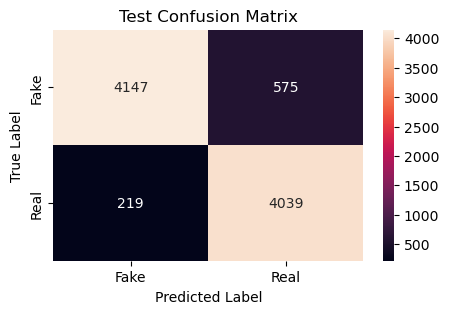

In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [46]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

clf = SVC()

param_grid = {'C':[0.1,1,10,100], 'kernel':['linear','rbf','poly','sigmoid']}

grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_news_tfidf, y_train)

best_params = grid_search.best_params_

final_clf = SVC(**best_params)
final_clf.fit(X_train_news_tfidf, y_train)

y_pred = final_clf.predict(X_test_news_tfidf)

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print('SVM Classifier')
print('Best hyperparameters:', best_params)
print('Accuracy: ', accuracy)
print('Precision: ', precision)
print('Recall: ', recall)
print('F1-score: ', f1)

SVM Classifier
Best hyperparameters: {'C': 10, 'kernel': 'rbf'}
Accuracy:  0.9582405345211581
Precision:  0.9565012932047966
Recall:  0.9553781117895725
F1-score:  0.9559393725766656


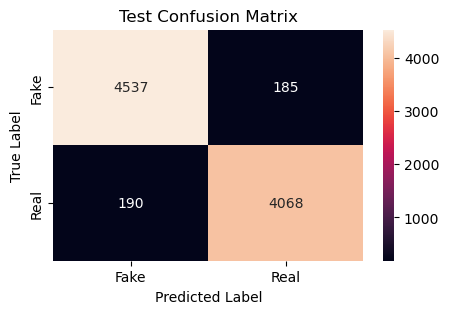

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

In [48]:
# DataFrame to csv

train_df.to_csv('train.tsv', sep='\t', index=False)
test_df.to_csv('test.tsv', sep='\t', index=False)